In [ ]:
!pip install torch torchvision==0.8.2+cu101 \
    -f https://download.pytorch.org/whl/cu101/torch_stable.html

!pip install pytorch-lightning \
            tensorboard==2.11 \
            numpy==1.22 \
            tqdm==4.59.0 \
            einops==0.4.1 \
            matplotlib==3.6.2

In [2]:
!lightning run app train.py --cloud

'lightning' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
!pip install tensorboardX
!pip install gdown
!pip install scikit-image

In [1]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from skimage.transform import resize

In [2]:
BASE_DIR = os.getcwd()
root_dir = f"{BASE_DIR}/dataset/original"
train_ddpm_dir = os.path.join(f'{BASE_DIR}/train_ddpm')

In [14]:
"""
This Cell form Downloading the original dataset
"""
def download_file(url, name, path='./data'):
    import os, requests

    if not os.path.exists(path):
        os.mkdir(path)

    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(os.path.join(path, name), "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
                    
    print(f"Download complete {name}.")

# urls = ["https://figshare.com/ndownloader/files/39181919", "https://figshare.com/ndownloader/files/39214622"]
# names = ["kf_2d_re1000_256_40seed.npy", "kf_2d_low_re1000_256_40seed.npz"]

# for url, name in zip(urls, names):
#     download_file(url, name, f"{os.getcwd()}/data")


In [2]:
# !gdown "https://drive.google.com/uc?id=1ZM50fC8W9DYKQ3YTJkhpNmSnBOQ87_Rg" -O dataset.zip
# !unzip dataset.zip -d dataset

Archive:  dataset.zip
replace dataset/original/t0000/R.mat? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [8]:
# origin = np.load('/teamspace/studios/this_studio/diffusion-2/data/kf_2d_re1000_256_40seed.npy')
# under_sampled = np.load('/teamspace/studios/this_studio/diffusion-2/data/kf_2d_low_re1000_256_40seed.npz', allow_pickle=True)
# print(under_sampled.files)

['u3232', 'idx_lst']


In [9]:
# under_sampled_data = under_sampled['u3232']
# idx_lst = under_sampled['idx_lst']

In [10]:
# idx_lst.shape

(40, 1024)

In [11]:
# idx_lst[0]

array([55458, 26836, 34921, ..., 19421, 23500,  8193])

In [12]:
def findxy(idx, w=256, h=256):
    x = idx % w
    y = idx // h
    return x, y

def show_section(original, sample, V, F, idx, dist=1):
    ov, of, oh, ow = original.shape
    if V > (ov - 1):
        raise ValueError(f"Please Enter V between 0 and {ov-1}")

    if F > (of - 1):
        raise ValueError(f"Please Enter F between 0 and {of-1}")
    
    col, row = findxy(idx, w=ow, h=oh)

    if (row > (oh - 1)) or (col > (ow - 1)):
        raise ValueError(f"Please enter index between 0 and {oh*ow - 1}")

    row_slice = slice(row-dist, row+dist+1) # [row-dist : row+dist+1]
    col_slice = slice(col-dist, col+dist+1)

    sample = sample[V, F][row_slice, col_slice]
    original = original[V, F][row_slice, col_slice]

    print("Sample:", sample, sep='\n')
    print("Origin:", original, sep='\n')

# params = dict(
#     original=origin,
#     sample=under_sampled_data,
#     V=0,
#     F=0,
#     idx=55458,
#     dist=2
# )

# show_section(**params)

Sample:
[[-0.48060337 -0.48060337 -0.48060337 -0.48060337 -0.48060337]
 [-0.48060337 -0.48060337 -0.48060337 -0.48060337 -0.48060337]
 [-0.48060337 -0.48060337 -0.48060337 -0.48060337 -0.48060337]
 [-0.48060337 -0.48060337 -0.48060337 -0.48060337 -0.48060337]
 [-0.64305258 -0.64305258 -0.64305258 -0.64305258 -0.64305258]]
Origin:
[[ 2.1461816   1.0215681  -0.3487493  -1.5122663  -2.099742  ]
 [ 2.0707393   0.9383039  -0.4168151  -1.5401468  -2.0877006 ]
 [ 1.9966004   0.8580408  -0.48060337 -1.564964   -2.0756643 ]
 [ 1.9241325   0.7813282  -0.53979576 -1.5867666  -2.0638916 ]
 [ 1.8537822   0.70874953 -0.5940619  -1.6055855  -2.0526178 ]]


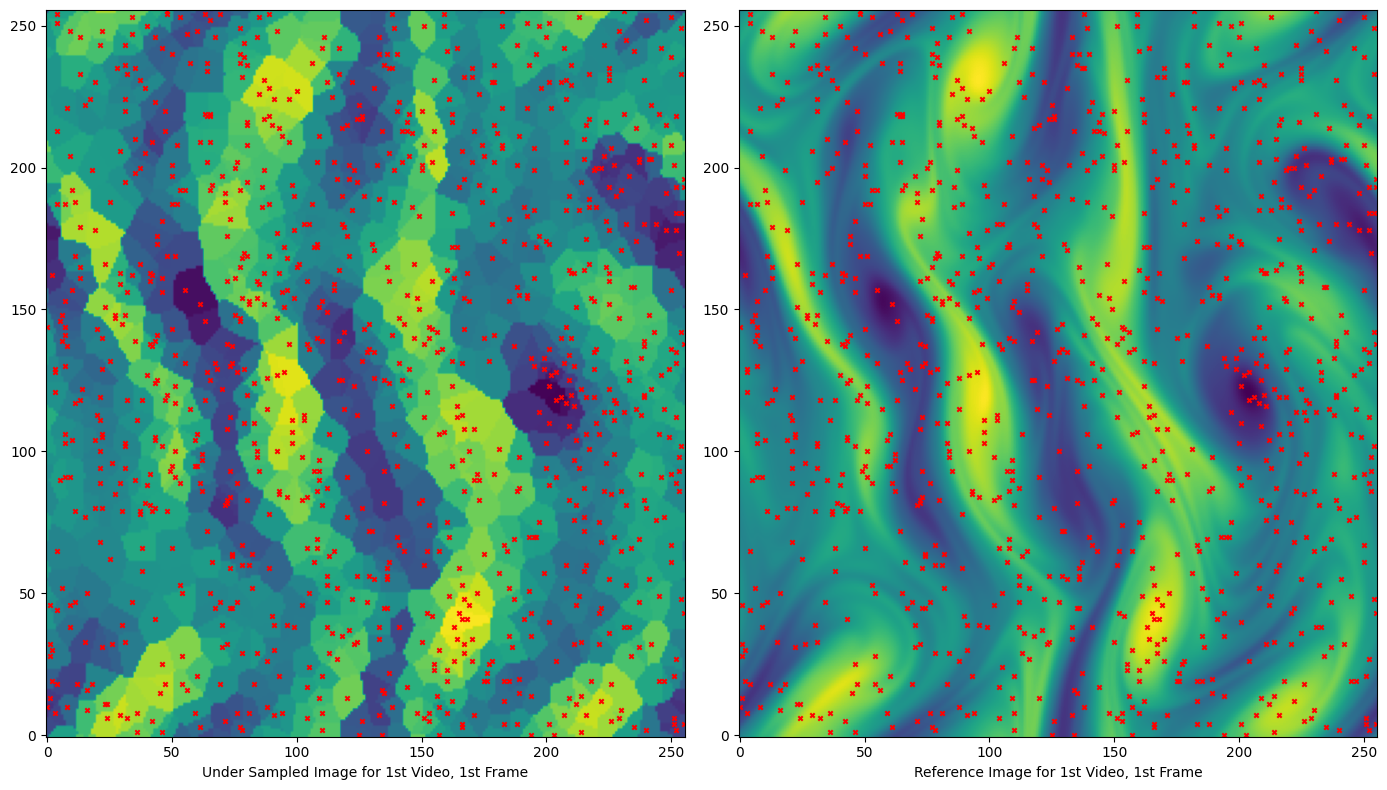

In [13]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# V, F = 0, 0
# h1 = ax1.imshow(under_sampled_data[V, F], cmap='viridis', origin='lower', aspect='auto')
# h2 = ax2.imshow(origin[V, F], cmap='viridis', origin='lower', aspect='auto')

# xy_points = np.array(list(map(findxy, idx_lst[V])))
# xs, ys = xy_points.T  # shape=(idx_lst[V], 2)

# ax1.scatter(xs, ys, s=10, marker='x', c='red')
# ax2.scatter(xs, ys, s=10, marker='x', c='red')

# ax1.set_xlabel('Under Sampled Image for 1st Video, 1st Frame')
# ax2.set_xlabel('Reference Image for 1st Video, 1st Frame')
# plt.tight_layout()
# plt.show()

In [16]:
def extract_dataset(root_dir):
    R_all, U_all, V_all = [], [], []

    for folder in sorted(os.listdir(root_dir)):
        folder_path = os.path.join(root_dir, folder)

        if os.path.isdir(folder_path) and folder.startswith("t"):
            r_mat = os.path.join(folder_path, "R.mat")
            if os.path.exists(r_mat):
                R_all.append(sio.loadmat(r_mat)["R_full"])
            
            u_mat = os.path.join(folder_path, "u.mat")
            if os.path.exists(u_mat):
                U_all.append(sio.loadmat(u_mat)["u_full"])

            v_mat = os.path.join(folder_path, "v.mat")
            if os.path.exists(v_mat):
                V_all.append(sio.loadmat(v_mat)["v_full"])


    data = {
        "r": np.array(R_all),
        "u": np.array(U_all),
        "v": np.array(V_all)
    }

    np.savez("dataset", **data, allow_pickle=True)
    print("✅ Done! Saved")

# extract_dataset(root_dir)

✅ Done! Saved


In [19]:
# ds = np.load(f"{BASE_DIR}/dataset.npz", allow_pickle=True)
# ds, ds_u, ds_v = ds['r'], ds['u'], ds['v']

In [5]:
# ds.shape

(521, 192, 1216)

In [20]:
def crop_dataset(ds, crop_h=256, crop_w=256, seg_frames=50):
    F, H, W = ds.shape

    if F < seg_frames:
        raise ValueError("Number of frames in the dataset must be greater than or equal to seg_frames.")
    
    out = []
    

    num_t_crops = F // seg_frames

    resolution = min(crop_h, H, crop_w, W)

    num_w_crops = max(W // resolution, 1)
    num_h_crops = max(H // resolution, 1)

    for t in range(num_t_crops):
        t_start = t * seg_frames
        t_end = t_start + seg_frames
        vid_t = ds[t_start:t_end]

        for h in range(num_h_crops):
            h_start = h * resolution
            h_end = min(h_start + resolution, H)

            # spatial cropping
            for w in range(num_w_crops):
                w_start = w * resolution
                w_end = min(w_start + resolution, W)
                vid_tw = vid_t[:, h_start:h_end, w_start:w_end]  # (seg_frames, H, W)

                vid_tw = resize(
                    vid_tw,
                    (seg_frames, crop_h, crop_w),
                    mode="reflect",
                    anti_aliasing=True
                )

                out.append(vid_tw)

    return np.array(out)


# Comment this section after transforming it
# dsets = {
#     '': ds,
#     '_u': ds_u,
#     '_v': ds_v
# }

# dsets[''], dsets['_u'], dsets['_v'] = [crop_dataset(data, crop_h=256, crop_w=256, seg_frames=60) for data in dsets.values()]
# [np.save(f"kf_2d_re1000_256_40seed{k}", v) for k,v in dsets.items()]
# print(dsets[''].shape, dsets['_u'].shape, dsets['_v'].shape, sep='\n')  # (48 , 60 , 256 , 256)

(48, 60, 256, 256)
(48, 60, 256, 256)
(48, 60, 256, 256)


In [ ]:
# !git clone https://github.com/BaratiLab/Diffusion-based-Fluid-Super-resolution.git

Cloning into 'Diffusion-based-Fluid-Super-resolution'...



In [ ]:
# !mkdir $BASE_DIR/data/

# !mv $BASE_DIR/kf_2d_re1000_256_40seed.npy $BASE_DIR/data/
# !mv $BASE_DIR/kf_2d_re1000_256_40seed_u.npy $BASE_DIR/data/
# !mv $BASE_DIR/kf_2d_re1000_256_40seed_v.npy $BASE_DIR/data/

In [ ]:
# !mkdir $BASE_DIR/train_ddpm/data/

# !cp $BASE_DIR/data/kf_2d_re1000_256_40seed.npy $BASE_DIR/train_ddpm/data/
# !cp $BASE_DIR/data/kf_2d_re1000_256_40seed_u.npy $BASE_DIR/train_ddpm/data/
# !cp $BASE_DIR/data/kf_2d_re1000_256_40seed_v.npy $BASE_DIR/train_ddpm/data/

In [23]:
ds = np.load(f'{train_ddpm_dir}/data/kf_2d_re1000_256_40seed.npy')
ds_u = np.load(f'{train_ddpm_dir}/data/kf_2d_re1000_256_40seed_u.npy')
ds_v = np.load(f'{train_ddpm_dir}/data/kf_2d_re1000_256_40seed_v.npy')
ds.shape

(48, 60, 256, 256)

In [3]:
%cd $train_ddpm_dir

/teamspace/studios/this_studio/diffusion-2/train_ddpm


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
!rm $train_ddpm_dir/km256_stats.npz
!rm $train_ddpm_dir/km256_u_stats.npz
!rm $train_ddpm_dir/km256_v_stats.npz

In [33]:
print(
    """
    if using lighting ai with 1 T4 and 32 memory    
    make the training batch = 8 in the file:    
    '/teamspace/studios/this_studio/diffusion-2/train_ddpm/configs/km_re1000_rs256_conditional.yml'
    """
    )


    if using lighting ai with 1 T4 and 32 memory    
    make the training batch = 8 in the file:    
    '/teamspace/studios/this_studio/diffusion-2/train_ddpm/configs/km_re1000_rs256_conditional.yml'
    


In [5]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [6]:
!python main.py \
    --config ./km_re1000_rs256_conditional.yml \
    --exp ./experiments/km256/ \
    --doc km256 \
    --resume_training \
    --ni

INFO - main.py - 2025-10-12 21:37:40,565 - Using device: cuda
INFO - main.py - 2025-10-12 21:37:40,566 - Writing log file to ./experiments/km256/logs/km256
INFO - main.py - 2025-10-12 21:37:40,567 - Exp instance id = 115612
INFO - main.py - 2025-10-12 21:37:40,567 - Exp comment = 
No dataset statistics found. Computing statistics...
Data set shape:  (48, 60, 256, 256)
Data statistics, mean: 10.900887200114799, scale: 1.793331747626696
Data set shape:  (48, 60, 256, 256)
Data statistics, mean: 10.853688182828959, scale: 1.8195050310978058
Data set shape:  (48, 60, 256, 256)
Data statistics, mean: -0.017974753178596977, scale: 0.9163530395362237
start_epoch: 112	 step: 35000
Starting training...
INFO - diffusion_tub.py - 2025-10-12 21:38:04,620 - step: 35001, loss: 2872.19091796875, data time: 0.32479405403137207
INFO - diffusion_tub.py - 2025-10-12 21:39:47,709 - step: 35101, loss: 1563.256591796875, data time: 0.013353373744700215
INFO - diffusion_tub.py - 2025-10-12 21:41:19,603 - ste

In [29]:
def get_stats(file_path):
    import os
    from datetime import datetime

    if os.path.exists(file_path):
        stat_info = os.stat(file_path)
        print(f"File Name: {os.path.basename(file_path)}")
        print(f"File Size: {stat_info.st_size} bytes")
        print(f"Creation Time: {datetime.fromtimestamp(stat_info.st_ctime)}")
        print(f"Modification Time: {datetime.fromtimestamp(stat_info.st_mtime)}")
        print(f"Access Time: {datetime.fromtimestamp(stat_info.st_atime)}")
        print(f"Permissions: {oct(stat_info.st_mode)}")
        print('='*30)
    else:
        print(f"File not found: {file_path}")

get_stats("/teamspace/studios/this_studio/diffusion-2/train_ddpm/experiments/km256/logs/km256/ckpt_1.pth")
get_stats("/teamspace/studios/this_studio/diffusion-2/train_ddpm/experiments/km256/logs/km256/ckpt.pth")

File Name: ckpt_1.pth
File Size: 56214497 bytes
Creation Time: 2025-10-12 03:36:25.721929
Modification Time: 2025-10-12 03:36:25.721929
Access Time: 2025-10-12 03:36:38.337362
Permissions: 0o100644
File Name: ckpt.pth
File Size: 56169477 bytes
Creation Time: 2025-10-12 06:19:15.984009
Modification Time: 2025-10-12 06:19:15.984009
Access Time: 2025-10-12 06:19:33.399969
Permissions: 0o100644
File Name: ckpt_5000.pth
File Size: 56223755 bytes
Creation Time: 2025-10-12 06:19:15.836009
Modification Time: 2025-10-12 06:19:15.836009
Access Time: 2025-10-12 06:19:33.395969
Permissions: 0o100644


In [24]:
os.chdir(os.path.join(os.getcwd(), '../'))

In [ ]:
!python main.py --config ./kmflow_re1000_rs256_conditional.yml --seed 1234 --sample_step 1 --t 240 --r 30